In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [2]:
train = pd.read_csv('/content/train.csv')
test = pd.read_csv('/content/test.csv')

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (1460, 81)
Test shape: (1459, 80)


In [3]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
X = train[['GrLivArea', 'BedroomAbvGr', 'FullBath']]
y = train['SalePrice']

print(X.head())
print(y.head())

   GrLivArea  BedroomAbvGr  FullBath
0       1710             3         2
1       1262             3         2
2       1786             3         2
3       1717             3         1
4       2198             4         2
0    208500
1    181500
2    223500
3    140000
4    250000
Name: SalePrice, dtype: int64


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1168, 3)
X_test: (292, 3)
y_train: (1168,)
y_test: (292,)


In [6]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [7]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[113410.67255298 305081.87775899 135904.78562983 205424.67564124
 227502.68349004 121157.48079629 205577.98056584 183787.20378269
 121157.48079629 147219.22233196]


In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 35788.061292436294
MSE: 2806426667.247853
RMSE: 52975.71771338122
R² Score: 0.6341189942328371


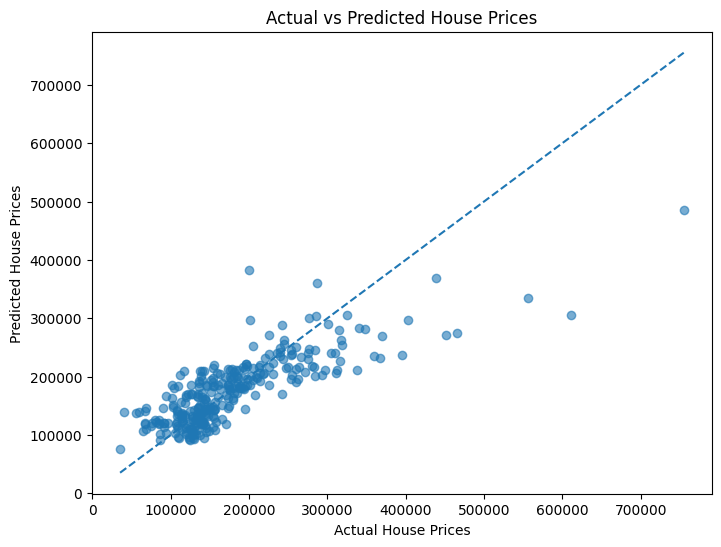

In [9]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Actual vs Predicted House Prices")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.show()

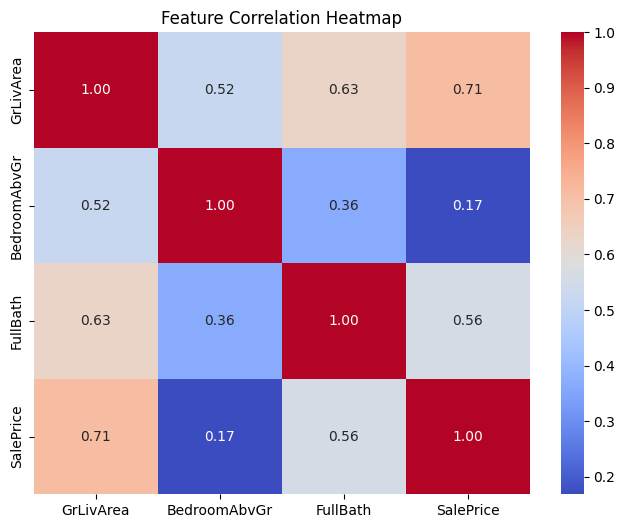

In [10]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    train[['GrLivArea', 'BedroomAbvGr', 'FullBath', 'SalePrice']].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Feature Correlation Heatmap")
plt.show()

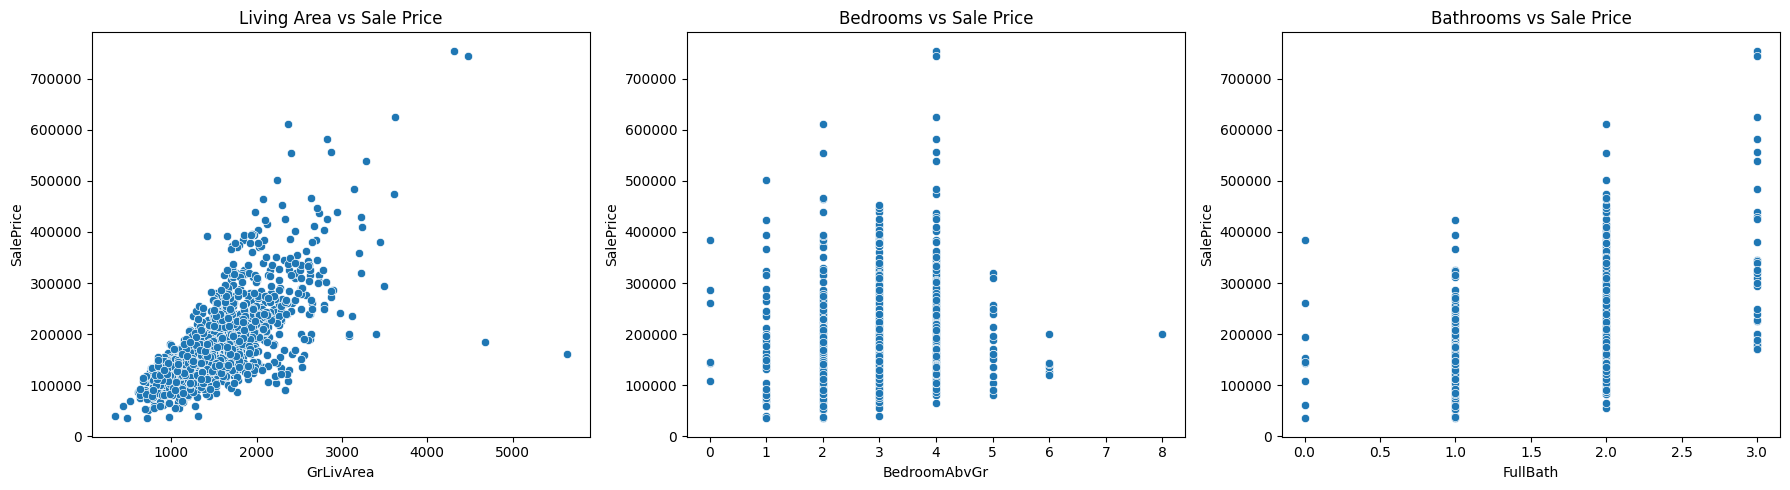

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(data=train, x='GrLivArea', y='SalePrice', ax=axes[0])
axes[0].set_title('Living Area vs Sale Price')

sns.scatterplot(data=train, x='BedroomAbvGr', y='SalePrice', ax=axes[1])
axes[1].set_title('Bedrooms vs Sale Price')

sns.scatterplot(data=train, x='FullBath', y='SalePrice', ax=axes[2])
axes[2].set_title('Bathrooms vs Sale Price')

plt.tight_layout()
plt.show()

In [12]:
comparison = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred
})

comparison.head(10)

,Actual Price,Predicted Price
0,154500,113410.672553
1,325000,305081.877759
2,115000,135904.785630
3,159000,205424.675641
4,315500,227502.683490
5,75500,121157.480796
6,311500,205577.980566
7,146000,183787.203783
8,84500,121157.480796
9,135500,147219.222332


In [13]:
test_features = test[['GrLivArea', 'BedroomAbvGr', 'FullBath']]

test_predictions = model.predict(test_features)

print(test_predictions[:10])

[122173.31310421 140561.53868318 201783.75489581 199183.09722051
 192133.73910587 204488.43887813 155804.12719639 184723.4405458
 168465.01972467 120716.94480604]


In [14]:
submission = pd.DataFrame({
    'Id': test['Id'],
    'SalePrice': test_predictions
})

submission.to_csv('submission.csv', index=False)

print("submission.csv created successfully!")
submission.head()

submission.csv created successfully!


,Id,SalePrice
0,1461,122173.313104
1,1462,140561.538683
2,1463,201783.754896
3,1464,199183.097221
4,1465,192133.739106


## Task 01 — House Price Prediction

### Model
Linear Regression

### Features Used
- GrLivArea — Living area / square footage
- BedroomAbvGr — Number of bedrooms
- FullBath — Number of full bathrooms

### Target
SalePrice

### Evaluation Results
- MAE: 35788.06
- MSE: 2806426667.25
- RMSE: 52975.72
- R² Score: 0.6341

### Visualizations
- Actual vs Predicted House Prices
- Feature Correlation Heatmap
- Feature vs Sale Price plots

### Output
Generated `submission.csv` containing predicted house prices for the test dataset.